In [ ]:
import pandas as pd
import numpy as np
from sklearn.cross_decomposition import CCA
from scipy.stats import chi2
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка и подготовка данных
df = pd.read_csv("canonical_lab_data.csv")  # путь к файлу
df_split = df.iloc[:, 0].str.split(';', expand=True)
df_split.columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
df_split = df_split.apply(pd.to_numeric)

# Формируем два набора переменных
X = df_split[['X1', 'X2', 'X3', 'X4']]  # Социально-экономические факторы
Y = df_split[['X5', 'X6', 'X7', 'X8']]  # Уровень жизни

In [ ]:
# 2. Статистика и корреляции
print("== Описательные статистики ==")
print(X.describe(), '\n')
print(Y.describe(), '\n')

print("== Корреляционная матрица X ==")
print(X.corr(), '\n')
print("== Корреляционная матрица Y ==")
print(Y.corr(), '\n')

== Описательные статистики ==
              X1         X2         X3         X4
count  48.000000  48.000000  48.000000  48.000000
mean    0.791667   2.187500   2.770833   0.479167
std     2.617115   3.564937   3.471707   3.940999
min   -10.000000 -10.000000 -10.000000 -10.000000
25%     0.000000   0.000000   0.750000   0.000000
50%     0.000000   3.000000   3.000000   0.000000
75%     3.000000   5.000000   5.000000   3.000000
max     5.000000  10.000000  10.000000  10.000000 

              X5         X6         X7         X8
count  48.000000  48.000000  48.000000  48.000000
mean    4.020833  30.625000  31.458333  21.562500
std     1.228900   7.117928   6.354621  11.584851
min     2.000000   5.000000   5.000000   0.000000
25%     3.000000  25.000000  25.000000  15.000000
50%     4.000000  35.000000  35.000000  25.000000
75%     4.250000  35.000000  35.000000  35.000000
max     9.000000  35.000000  35.000000  35.000000 

== Корреляционная матрица X ==
          X1        X2        X3   

Внутри X-набора наблюдается умеренная взаимосвязь между приростом промышленного производства и ростом доходов (X1–X4: 0.60).
В Y-наборе слабая корреляция между числом членов семьи (X5) и остальными показателями (все корреляции < 0.25).
В целом, внутри наборов есть некоторая связь, но она умеренная — это условно допускает применение метода CCA, но сильных линейных зависимостей нет.

In [ ]:
# 3. Канонический корреляционный анализ
cca = CCA(n_components=min(X.shape[1], Y.shape[1]))
X_c, Y_c = cca.fit_transform(X, Y)

# Канонические корреляции
canonical_corrs = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(X_c.shape[1])]
canonical_corrs_squared = np.square(canonical_corrs)

# Хи-квадрат проверка значимости
n, p, q = X.shape[0], X.shape[1], Y.shape[1]
chi_stats, p_values, dofs = [], [], []

for i, r2 in enumerate(canonical_corrs_squared):
    df = (p - i) * (q - i)
    stat = -(n - 1 - (p + q + 1) / 2) * np.log(1 - r2)
    chi_stats.append(stat)
    p_values.append(chi2.sf(stat, df))
    dofs.append(df)

results = pd.DataFrame({
    "Канон. корреляция": canonical_corrs,
    "Собств. значение": canonical_corrs_squared,
    "Хи-квадрат": chi_stats,
    "Степени свободы": dofs,
    "p-значение": p_values
})
print("== Результаты анализа ==")
print(results, '\n')

== Результаты анализа ==
   Канон. корреляция  Собств. значение  Хи-квадрат  Степени свободы  \
0           0.455196          0.207204    9.868037               16   
1           0.234002          0.054757    2.393304                9   
2           0.114586          0.013130    0.561721                4   
3           0.014527          0.000211    0.008969                1   

   p-значение  
0    0.873428  
1    0.983617  
2    0.967221  
3    0.924548   



Наиболее сильная связь между первым каноническим фактором U1 (X) и V1 (Y): корреляция 0.455.
Однако, p-значения для всех компонент > 0.05, следовательно, ни одна пара канонических переменных не является статистически значимой.
Это значит, что нет достоверной линейной связи между двумя наборами переменных.

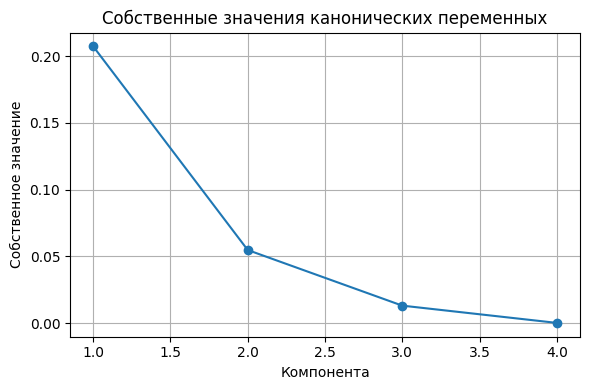

In [ ]:
# 5. График собственных значений
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(canonical_corrs_squared)+1), canonical_corrs_squared, marker='o')
plt.title("Собственные значения канонических переменных")
plt.xlabel("Компонента")
plt.ylabel("Собственное значение")
plt.grid(True)
plt.tight_layout()
plt.show()

С математической точки зрения, первая пара канонических переменных содержит максимум информации.
Но с точки зрения статистической значимости, все компоненты, включая первую, не прошли проверку по критерию χ², и их использование для интерпретации не обосновано.
Это подтверждает, что между выбранными наборами переменных нет статистически значимой линейной зависимости.

In [ ]:
# 6. Канонические веса
x_weights = pd.DataFrame(cca.x_weights_, index=X.columns, columns=[f'U{i+1}' for i in range(cca.x_weights_.shape[1])])
y_weights = pd.DataFrame(cca.y_weights_, index=Y.columns, columns=[f'V{i+1}' for i in range(cca.y_weights_.shape[1])])

print("== Канонические веса (X) ==")
print(x_weights, '\n')
print("== Канонические веса (Y) ==")
print(y_weights, '\n')

== Канонические веса (X) ==
          U1        U2        U3        U4
X1  0.003380  0.661946  0.487067 -0.569721
X2  0.248625  0.314723  0.481839  0.779080
X3  0.470918 -0.630411  0.566074 -0.245718
X4  0.846410  0.255653 -0.458428 -0.089862 

== Канонические веса (Y) ==
          V1        V2        V3        V4
X5  0.570423  0.129843  0.540805  0.604391
X6  0.553662 -0.552542  0.205849 -0.588032
X7  0.196605 -0.566042 -0.627336  0.497385
X8 -0.573954 -0.597858  0.521158  0.203807 



U1 = 0.0034⋅X1 + 0.2486⋅X2 + 0.4709⋅X3 + 0.8464⋅X4

Наибольший вклад в U₁ даёт прирост доходов населения (X4) и темп прироста цен (X3) — это говорит о том, что первая каноническая переменная отражает динамику потребительского спроса и доходов.

V1 = 0.5704⋅X5 + 0.5537⋅X6 + 0.1966⋅X7 - 0.5739⋅X8

В V₁ основной вклад дают размер семьи (X5), реальный доход (X6) и отрицательно — нагрузка по обязательствам (X8).
V₁ можно интерпретировать как индикатор доходной стабильности семьи, скорректированной на долю финансовых обязательств.

In [ ]:
# 7. Факторные структуры
x_loadings = pd.DataFrame(np.corrcoef(X.T, X_c.T)[:p, p:], index=X.columns,
                          columns=[f"U{i+1}" for i in range(X_c.shape[1])])
y_loadings = pd.DataFrame(np.corrcoef(Y.T, Y_c.T)[:q, q:], index=Y.columns,
                          columns=[f"V{i+1}" for i in range(Y_c.shape[1])])

print("== Факторные структуры (X) ==")
print(x_loadings, '\n')
print("== Факторные структуры (Y) ==")
print(y_loadings, '\n')

== Факторные структуры (X) ==
          U1        U2        U3        U4
X1  0.730442  0.455975  0.336042 -0.381598
X2  0.524492  0.171796  0.650455  0.521827
X3  0.634128 -0.575757  0.489182 -0.164581
X4  0.841842  0.268050 -0.464573 -0.060189 

== Факторные структуры (Y) ==
          V1        V2        V3        V4
X5  0.489926  0.030137  0.620690  0.611399
X6  0.678681 -0.411735  0.126571 -0.594850
X7  0.410162 -0.515529 -0.559316  0.503152
X8 -0.601777 -0.543818  0.547376  0.206170 



U₁ наиболее тесно связан с темпом прироста доходов (X4) и промышленным производством (X1), также с ростом цен.
U₁ можно интерпретировать как обобщённую характеристику экономической активности и доходной динамики населения.

V₁ наиболее сильно связан с фактическим доходом (X6) и обратной зависимостью от финансовой нагрузки (X8).
V₁ можно интерпретировать как обобщённую характеристику финансового положения и устойчивости домохозяйства.

